# sc2ts on a simulated coronavirus: pilot

A first look at how well sc2ts recovers recombinants and the overall ARG when the
truth is known, using the SLiM pipeline in `simulations/slim`.

**Simulation.** A neutral, haploid Wright-Fisher population grows from a single founder
to 1,000 cases per generation over 20 generations, then stays at that size for 80
more (100 generations in all, ~83k individuals). The genome is 30 kb, with a mutation
rate of $1.2 \times 10^{-5}$ per site per generation: 0.0008 substitutions per site per
year with a 5.5 day generation time, as in the synthetic recombinant analysis, or about
0.36 mutations per genome per generation. 1% of births have two parents, with a single
uniformly placed breakpoint. Each generation is one sampling date for sc2ts.

**Sampling and inference.** Individuals are sampled from every generation with
probability $P = 0.02$ (1,643 samples) or $P = 0.1$ (8,226), with the samples at 0.02
a subset of those at 0.1. sc2ts is run with $k = 3, 4, 5$ and otherwise the parameters
used for the Viridian ARG. One replicate.

**What counts as a recombinant.** A sample should be inferred to be a recombinant if it
is one itself, *or* if it inherits a recombination from an unsampled ancestor: walking
up its clonal line, it reaches a recombinant before reaching any individual placed in
the inferred ARG. Several samples can share one such recombinant ancestor; once sc2ts
has inferred that recombination in one of them, the rest correctly copy from it with
a single parent. So:

- **precision** is per sample: of the samples sc2ts matched with two parents, the
  fraction expected to be recombinants;
- **recall** is per recombination *event*: the fraction of recombinant ancestors for
  which at least one expected sample was matched with two parents.

Only samples sc2ts placed in the ARG are scored.

Produced with:
```
cd simulations/slim
snakemake --cores 4 results/coronavirus/summary.csv --config 'p_values=[0.02,0.1]'
```
and `results/coronavirus/{summary,events,placement}.csv` copied to
`simulations/slim/pilot/` as `coronavirus_*.csv`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
results_dir = Path("../simulations/slim/pilot")
# One row per run.
summary = pd.read_csv(results_dir / "coronavirus_summary.csv")
# One row per expected recombination event per run.
events = pd.read_csv(results_dir / "coronavirus_events.csv")
# Samples and placed samples per generation per run.
placement = pd.read_csv(results_dir / "coronavirus_placement.csv")

p_values = sorted(summary.p.unique())
k_values = sorted(summary.k.unique())
summary.shape, events.shape, placement.shape

((6, 24), (821, 13), (561, 7))

In [3]:
# k and P are both ordered, so each is one hue stepped light to dark.
k_colors = dict(zip(k_values, ["#86b6ef", "#2a78d6", "#104281"]))
p_colors = dict(zip(p_values, ["#86b6ef", "#104281"]))
grid_kwargs = dict(color="0.9", linewidth=0.6)

# The median breakpoint interval in the Viridian ARG, from the paper.
PAPER_MEDIAN_INTERVAL = 2018


def clean_axes(ax):
    ax.yaxis.grid(True, **grid_kwargs)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

## Summary

`sampled` is the number of placed samples that are recombinants themselves, `expected`
the number that should be inferred to be recombinants, and `events` the number of
distinct recombinant ancestors behind them.

In [4]:
table = summary.set_index(["p", "k"])[
    [
        "num_samples",
        "num_placed",
        "num_sampled_recombinants",
        "num_expected_recombinants",
        "num_events",
        "num_inferred_recombinants",
        "false_positives",
        "precision",
        "events_detected",
        "recall",
        "recall_detectable",
        "breakpoint_in_interval",
    ]
].rename(
    columns=lambda c: c.replace("num_", "").replace("_recombinants", "")
)
table.round(3)

samples  placed  sampled  expected  events  inferred  false_positives  \
p    k                                                                          
0.02 3     1643     940        5       100      39        16                0   
     4     1643     924        5        86      36        11                0   
     5     1643     888        4        63      30         5                0   
0.10 3     8226    5866       69       634     252       223                5   
     4     8226    5825       69       611     241       219                9   
     5     8226    5794       64       592     223       176                6   

        precision  events_detected  recall  recall_detectable  \
p    k                                                          
0.02 3      1.000               16   0.410              0.432   
     4      1.000               11   0.306              0.324   
     5      1.000                5   0.167              0.179   
0.10 3      0.978              183   0.726              0.756   
     4      0.959              151   0.627              0.654   
     5      0.966              123   0.552              0.577   

        breakpoint_in_interval  
p    k                          
0.02 3                   1.000  
     4                   1.000  
     5                   1.000  
0.10 3                   0.995  
     4                   0.987  
     5                   0.984

## Precision and recall

Raising $k$ trades recall for precision, as on the real data, but precision is high
throughout: almost every sample sc2ts reports as a recombinant really does carry an
unrepresented recombination. Recall depends much more on how densely the epidemic is
sampled than on $k$.

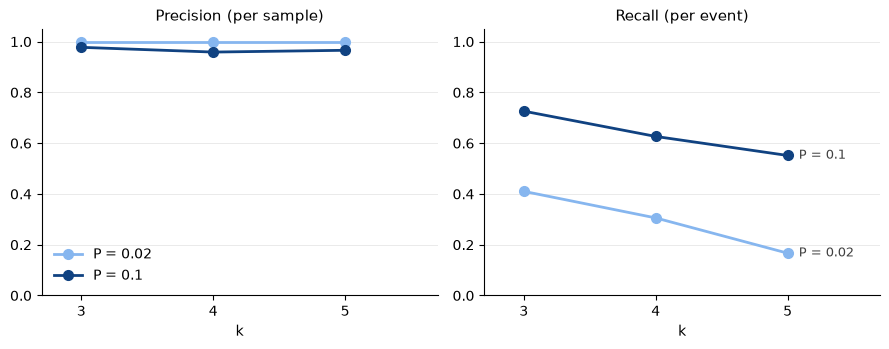

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True)
for ax, column, title in zip(
    axes, ["precision", "recall"], ["Precision (per sample)", "Recall (per event)"]
):
    for p in p_values:
        df = summary[summary.p == p].sort_values("k")
        ax.plot(
            df.k, df[column], marker="o", markersize=7, linewidth=2,
            color=p_colors[p], label=f"P = {p}",
        )
        # Precision lines sit too close together to label directly.
        if column == "recall":
            ax.annotate(
                f"P = {p}", xy=(df.k.iloc[-1], df[column].iloc[-1]),
                xytext=(8, 0), textcoords="offset points", va="center", fontsize=9,
                color="0.25",
            )
    ax.set_title(title, fontsize=11)
    ax.set_xticks(k_values)
    ax.set_xlabel("k")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(k_values[0] - 0.3, k_values[-1] + 0.7)
    clean_axes(ax)
axes[0].legend(frameon=False, loc="lower left")
fig.tight_layout()

## Which events are found

Detectable events (where the recombinant differs from both its parents; the rest leave
no trace), split by whether the recombinant itself was sampled and placed, or is only
seen through its descendants. Recall is similar either way: sc2ts finds unsampled
recombinants through their descendants about as well as it finds sampled ones.

In [6]:
events["kind"] = np.where(events.sampled, "recombinant sampled", "descendants only")
(
    events[events.detectable]
    .groupby(["p", "k", "kind"])
    .detected.agg(["size", "mean"])
    .rename(columns={"size": "events", "mean": "recall"})
    .unstack("kind")
    .round(3)
)

events                               recall  \
kind   descendants only recombinant sampled descendants only   
p    k                                                         
0.02 3               32                   5            0.406   
     4               29                   5            0.310   
     5               24                   4            0.167   
0.10 3              175                  67            0.766   
     4              164                  67            0.665   
     5              151                  62            0.603   

                            
kind   recombinant sampled  
p    k                      
0.02 3               0.600  
     4               0.400  
     5               0.250  
0.10 3               0.731  
     4               0.627  
     5               0.516

## Placement

A large fraction of samples are never placed in the ARG: 44% at $P = 0.02$ and 29% at
$P = 0.1$. sc2ts defers samples whose best match costs more than `hmm_cost_threshold`
(7), and only adds them later in retrospective groups of at least 10. At $P = 0.1$ the
placed fraction is steady at around 0.7, but at $P = 0.02$ it falls from about 0.8 to
under 0.2 over the course of the epidemic. That points to a feedback with sparse
sampling: every unplaced sample leaves the next generation's samples further from
anything in the ARG, pushing more of them over the threshold.

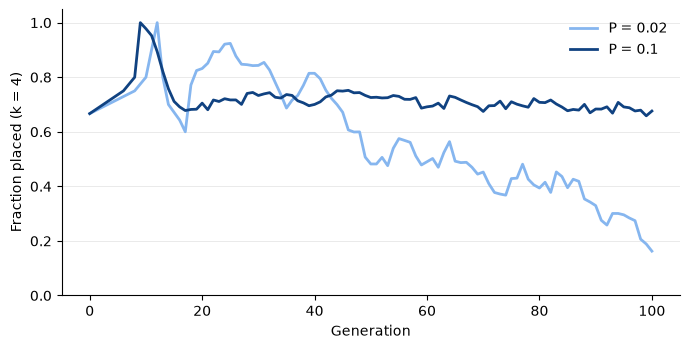

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for p in p_values:
    df = placement[(placement.p == p) & (placement.k == 4)].set_index("gen")
    rate = df.num_placed / df.num_samples
    # Smooth over 5 generations: few samples per generation at P = 0.02.
    smooth = rate.rolling(5, center=True, min_periods=1).mean()
    ax.plot(smooth.index, smooth.values, linewidth=2, color=p_colors[p], label=f"P = {p}")
ax.set_xlabel("Generation")
ax.set_ylabel("Fraction placed (k = 4)")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False)
clean_axes(ax)
fig.tight_layout()

In [8]:
df = placement[placement.k == 4].groupby("p")[["num_samples", "num_placed"]].sum()
(df.num_placed / df.num_samples).round(3)

p
0.02    0.562
0.10    0.708
dtype: float64

## Breakpoints

Breakpoint intervals run from the last site supporting the left parent to the first
supporting the right. For events found with a single breakpoint (taking the earliest
sample the event was found in), the true breakpoint falls in the interval almost every
time. Interval widths are of the same order as in the
real ARG (dashed line; median about 1,400 bases here at $P = 0.1$ against 2,018), as
expected with a similar per-genome mutation rate.

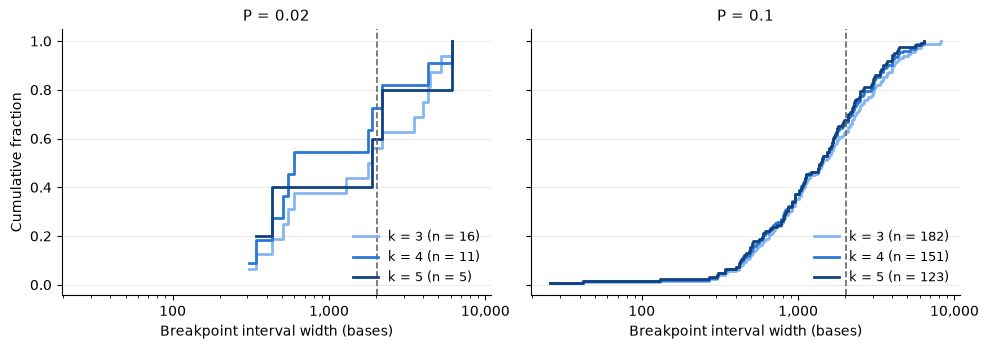

In [9]:
# Events found with a single breakpoint have an interval.
found = events.dropna(subset=["interval_width"])

fig, axes = plt.subplots(1, len(p_values), figsize=(10, 3.6), sharex=True, sharey=True)
for ax, p in zip(axes, p_values):
    for k in k_values:
        width = np.sort(found[(found.p == p) & (found.k == k)].interval_width.values)
        ax.step(
            width, np.arange(1, len(width) + 1) / len(width), where="post",
            linewidth=2, color=k_colors[k], label=f"k = {k} (n = {len(width)})",
        )
    ax.axvline(PAPER_MEDIAN_INTERVAL, color="0.4", linestyle="--", linewidth=1.2)
    ax.set_title(f"P = {p}", fontsize=11)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel("Breakpoint interval width (bases)")
    ax.legend(frameon=False, loc="lower right", fontsize=9)
    clean_axes(ax)
axes[0].set_ylabel("Cumulative fraction")
fig.tight_layout()

In [10]:
found.groupby(["p", "k"]).interval_width.median()

p     k
0.02  3    1834.5
      4     594.0
      5    1896.0
0.10  3    1437.0
      4    1404.0
      5    1393.0
Name: interval_width, dtype: float64

## ARG accuracy

`tscompare.haplotype_arf(inferred, true)`, over the placed samples. `arf` is the
fraction of the inferred ARG's node span not found in the true ARG, `tpr` the fraction
of the true ARG's span found in the inferred one, and `rmse` the error in log node
times (in generations) of matched nodes.

In [11]:
summary.set_index(["p", "k"])[["arf", "tpr", "rmse"]].round(3)

arf    tpr   rmse
p    k                     
0.02 3  0.171  0.615  0.043
     4  0.167  0.620  0.043
     5  0.167  0.620  0.042
0.10 3  0.174  0.621  0.064
     4  0.176  0.621  0.064
     5  0.177  0.620  0.065

## Notes

- Precision is high at every $k$: the few false positives (at most 9 of 219 at
  $P = 0.1$) are worth looking at individually.
- Recall is low at $P = 0.02$, which is also where placement collapses over time. The
  same mechanism, sparse sampling leaving new samples far from anything in the ARG,
  probably explains both, so the next step is to separate the effect of the placement
  thresholds (`hmm_cost_threshold`, `min_group_size`) from that of $k$.
- ARF and TPR barely change with $k$ or $P$. Recombination is rare enough that
  the clonal topology dominates the node-span comparison, so these are measuring
  tree accuracy more than recombinant accuracy.
- One replicate, one parameter set: no uncertainty estimates yet.